# AI-ML Assignment

## Movie Recommendation System

**Name:** Rathlavath Karthik

**Registration Number:** 23BCE11601

**Application Number:** IN26010749

**Batch Number:** 2(B)

# Task 1: Data Collection and Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

In [2]:
from google.colab import files

uploaded = files.upload()

Saving ml-latest-small.zip to ml-latest-small.zip


In [3]:
zip_path = "/content/ml-latest-small.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/movielens")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [4]:
movies = pd.read_csv("/content/movielens/ml-latest-small/movies.csv")
ratings = pd.read_csv("/content/movielens/ml-latest-small/ratings.csv")

print("Movies Dataset Shape:", movies.shape)
print("Ratings Dataset Shape:", ratings.shape)

Movies Dataset Shape: (9742, 3)
Ratings Dataset Shape: (100836, 4)


In [5]:
print("Movies Dataset")
movies.head()

Movies Dataset


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
print("Ratings Dataset")
ratings.head()

Ratings Dataset


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
print("Movies Dataset Info")
movies.info()

print("\nRatings Dataset Info")
ratings.info()

Movies Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB

Ratings Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


# Task 2: Data Preprocessing

In [8]:
print("Missing Values in Movies Dataset")
print(movies.isnull().sum())

print("\nMissing Values in Ratings Dataset")
print(ratings.isnull().sum())

Missing Values in Movies Dataset
movieId    0
title      0
genres     0
dtype: int64

Missing Values in Ratings Dataset
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [9]:
movie_data = pd.merge(ratings, movies, on="movieId")

print("Merged Dataset Shape:", movie_data.shape)

movie_data.head()

Merged Dataset Shape: (100836, 6)


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [10]:
movie_data = movie_data.drop(columns=["timestamp"])

print(movie_data.columns)

Index(['userId', 'movieId', 'rating', 'title', 'genres'], dtype='object')


In [11]:
movie_ratings = movie_data.groupby("title")["rating"].mean().reset_index()

movie_ratings.rename(columns={"rating":"Average_Rating"}, inplace=True)

movie_ratings.head()

,title,Average_Rating
0,'71 (2014),4.0
1,'Hellboy': The Seeds of Creation (2004),4.0
2,'Round Midnight (1986),3.5
3,'Salem's Lot (2004),5.0
4,'Til There Was You (1997),4.0


In [12]:
rating_count = movie_data.groupby("title")["rating"].count().reset_index()

rating_count.rename(columns={"rating":"Rating_Count"}, inplace=True)

rating_count.head()

,title,Rating_Count
0,'71 (2014),1
1,'Hellboy': The Seeds of Creation (2004),1
2,'Round Midnight (1986),2
3,'Salem's Lot (2004),1
4,'Til There Was You (1997),2


In [13]:
movie_summary = pd.merge(movie_ratings, rating_count, on="title")

movie_summary.head()

,title,Average_Rating,Rating_Count
0,'71 (2014),4.0,1
1,'Hellboy': The Seeds of Creation (2004),4.0,1
2,'Round Midnight (1986),3.5,2
3,'Salem's Lot (2004),5.0,1
4,'Til There Was You (1997),4.0,2


# Task 3: Movie Recommendation System

In [14]:
user_movie_matrix = movie_data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

print("User-Movie Matrix Shape:", user_movie_matrix.shape)

user_movie_matrix.head()

User-Movie Matrix Shape: (610, 9719)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
movie_correlation = user_movie_matrix.corr(method="pearson")

print("Correlation Matrix Shape:", movie_correlation.shape)

Correlation Matrix Shape: (9719, 9719)


In [16]:
def recommend_movies(movie_name, num_recommendations=5):

    if movie_name not in movie_correlation.columns:
        print("Movie not found in dataset.")
        return

    recommendations = movie_correlation[movie_name].sort_values(
        ascending=False
    )[1:num_recommendations+1]

    print(f"\nTop {num_recommendations} Recommendations for '{movie_name}':\n")

    print(recommendations)

In [17]:
recommend_movies("Toy Story (1995)")


Top 5 Recommendations for 'Toy Story (1995)':

title
Brigadoon (1954)                                      1.0
Claim, The (2000)                                     1.0
Hearts of Darkness: A Filmmakers Apocalypse (1991)    1.0
Stalker (1979)                                        1.0
Eddie Murphy Delirious (1983)                         1.0
Name: Toy Story (1995), dtype: float64


In [18]:
movie_summary.sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

,title,Average_Rating,Rating_Count
4699,Karlson Returns (1970),5.0,1
9685,Zeitgeist: Moving Forward (2011),5.0,1
2578,"Dream of Light (a.k.a. Quince Tree Sun, The) (...",5.0,1
2571,Dragons: Gift of the Night Fury (2011),5.0,1
35,12 Angry Men (1997),5.0,1
4681,Justice League: Doom (2012),5.0,1
4658,Junior and Karlson (1968),5.0,1
4647,Jump In! (2007),5.0,1
4122,"Human Condition III, The (Ningen no joken III)...",5.0,1
5239,Louis Theroux: Law & Disorder (2008),5.0,1


# Task 4: Recommendation System Evaluation

In [19]:
sample_movie = "Toy Story (1995)"

print("Movie Selected:", sample_movie)

recommend_movies(sample_movie)

Movie Selected: Toy Story (1995)

Top 5 Recommendations for 'Toy Story (1995)':

title
Brigadoon (1954)                                      1.0
Claim, The (2000)                                     1.0
Hearts of Darkness: A Filmmakers Apocalypse (1991)    1.0
Stalker (1979)                                        1.0
Eddie Murphy Delirious (1983)                         1.0
Name: Toy Story (1995), dtype: float64


In [20]:
top_movies = movie_summary.sort_values(
    by="Rating_Count",
    ascending=False
)

top_movies.head(10)

,title,Average_Rating,Rating_Count
3158,Forrest Gump (1994),4.164134,329
7593,"Shawshank Redemption, The (1994)",4.429022,317
6865,Pulp Fiction (1994),4.197068,307
7680,"Silence of the Lambs, The (1991)",4.161290,279
5512,"Matrix, The (1999)",4.192446,278
8001,Star Wars: Episode IV - A New Hope (1977),4.231076,251
4662,Jurassic Park (1993),3.750000,238
1337,Braveheart (1995),4.031646,237
8363,Terminator 2: Judgment Day (1991),3.970982,224
7421,Schindler's List (1993),4.225000,220


<Figure size 1000x600 with 0 Axes>

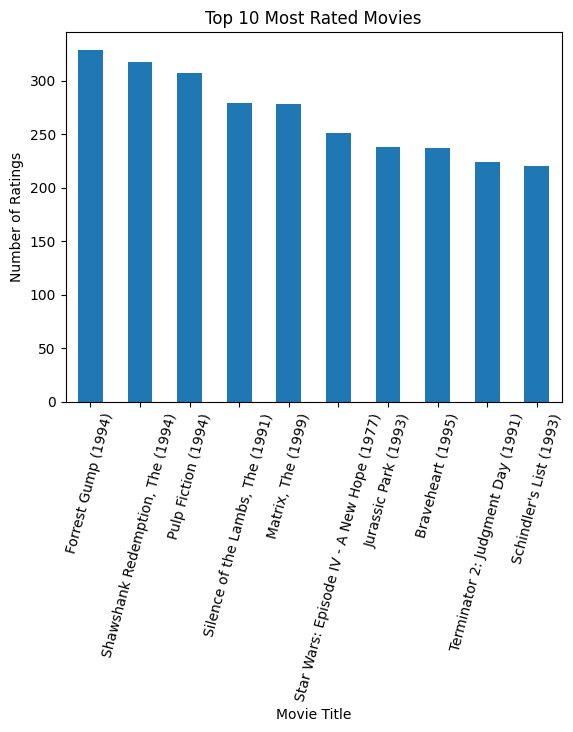

In [21]:
plt.figure(figsize=(10,6))

top_movies.head(10).plot(
    x="title",
    y="Rating_Count",
    kind="bar",
    legend=False
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Number of Ratings")

plt.xticks(rotation=75)

plt.show()

## Observations

1. The recommendation system suggests movies that have similar user rating patterns to the selected movie.

2. Movies with a higher number of ratings generally produce more reliable recommendations because they have more user feedback.

3. Correlation-based recommendation works effectively for users with similar preferences but may provide fewer recommendations for movies with very few ratings.

# Task 5: Conclusion

The Movie Recommendation System was successfully developed using the MovieLens dataset. The ratings and movie information were merged to create a user-movie matrix, and Pearson correlation was used to identify similarities between movies. The recommendation function was able to suggest movies that are closely related to a selected movie based on user rating behavior. The system demonstrates how collaborative filtering can be used to improve user experience by providing personalized recommendations. One major advantage of this approach is its simplicity and effectiveness when sufficient user ratings are available. However, it may perform poorly for newly added movies or users with very few ratings, commonly known as the cold-start problem.